In [1]:
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit import DataStructs
from rdkit.Chem import AllChem, MACCSkeys, rdMolDescriptors, rdFingerprintGenerator
from rdkit.Chem.Fingerprints import FingerprintMols

from rdkit.Chem import Draw, rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Chem.Draw import IPythonConsole 
from rdkit.Chem.Draw.MolDrawing import MolDrawing, DrawingOptions

from rdkit import rdBase
rdBase.DisableLog('rdApp.*')

IPythonConsole.ipython_useSVG = True
from IPython.display import display, SVG

import pandas as pd
import numpy as np
import os

from sklearn.utils import shuffle
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier

import pickle
import random
import seaborn as sns
from rdkit.Chem import rdFingerprintGenerator, MACCSkeys, DataStructs
from collections import Counter

In [2]:
def get_e3_mol(label):
    e3_smiles = label.split('.')[0]  # Extracting e3 part
    return Chem.MolFromSmiles(e3_smiles)

def get_linker_mol(label):
    linker_smiles = label.split('.')[1]  # Extracting linker part
    return Chem.MolFromSmiles(linker_smiles)

def get_poi_mol(label):
    poi_smiles = label.split('.')[2]  # Extracting poi part
    return Chem.MolFromSmiles(poi_smiles)

In [ ]:
train_df = pd.read_parquet('../PROTAC-Splitter/data/clustered/train-00000-of-00001.parquet')
test_df=pd.read_csv('../PROTAC-Splitter/data/Internal_after_curation.csv')
test_df.columns

Index(['Unnamed: 0', 'text', 'POI Ligand SMILES with direction',
       'E3 Binder SMILES with direction', 'Linker SMILES with direction',
       'POI Ligand SMILES', 'E3 Binder SMILES', 'Linker SMILES', 'PROTAC ID',
       'POI Ligand ID', 'E3 Binder ID', 'Linker ID', 'Notes', 'Compound Name',
       'labels'],
      dtype='object')

In [4]:

def get_tanimoto_distr_2sets(ref_mols, sampled_mols_list, FP='', radius=2):
    # Compute Tanimoto similarity to reference compound, only return highest similarity.

    ref_fps = []
    if FP == 'rdkit':
        rdkgen = rdFingerprintGenerator.GetRDKitFPGenerator(fpSize=512)
        ref_fps = [rdkgen.GetFingerprint(m) for m in ref_mols]
    elif FP == 'atompair':
        apgen = rdFingerprintGenerator.GetAtomPairGenerator(fpSize=2048)
        ref_fps = [apgen.GetFingerprint(m) for m in ref_mols]
    elif FP == 'maccskeys':
        ref_fps = [MACCSkeys.GenMACCSKeys(m) for m in ref_mols]
    else:
        mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=2048)
        ref_fps = [mfpgen.GetFingerprint(m) for m in ref_mols]

    all_similarities = []
    all_indexes = []

    dissimilar_mols = []

    for sampled_mols in sampled_mols_list:
        sim_list = []
        ref_idx_list = []
        for sample in sampled_mols:
            if FP == 'rdkit':
                mfp = rdkgen.GetFingerprint(sample)
            elif FP == 'atompair':
                mfp = apgen.GetFingerprint(sample)
            elif FP == 'maccskeys':
                mfp = MACCSkeys.GenMACCSKeys(sample)
            else:
                mfp = mfpgen.GetFingerprint(sample)

            sim_sample = 0
            ref_index = ''
            for idx in range(0, len(ref_fps)):
                ts = DataStructs.TanimotoSimilarity(mfp, ref_fps[idx])
                if ts > sim_sample:
                    sim_sample = ts
                    ref_index = idx
                if sim_sample >= 0.99:
                    break
                #bit_differences.extend(compare_maccs_bit_difference(ref_mols[ref_index], sample))
            if sim_sample < 0.2:
                dissimilar_mols.append(sample)
                # Collect differing bits for visualization
                
            sim_list.append(sim_sample)
            ref_idx_list.append(ref_index)

        all_similarities.append(sim_list)
        all_indexes.append(ref_idx_list)

    # Calculate frequency of differing bits
    #bit_frequency = Counter(bit_differences)
    
    # Plot the bit differences
    #plot_bit_differences(bit_frequency)

    return all_similarities, dissimilar_mols, all_indexes

In [5]:

def plot_tanimoto_similarity_2sets(ref_mols, samples_mols, path, name):
    # Compute similarities for different fingerprint types
    similarities_morganFP, _, _ = get_tanimoto_distr_2sets(ref_mols, [samples_mols])
    similarities_pathFP, _, _ = get_tanimoto_distr_2sets(ref_mols, [samples_mols], 'rdkit')
    similarities_maccskeys, _, _ = get_tanimoto_distr_2sets(ref_mols, [samples_mols], 'maccskeys')
    
    # Set up the figure with subplots
    fig, axes = plt.subplots(3, 1, figsize=(8, 12))
    
    # Plot Morgan Fingerprint Histogram
    axes[0].hist(similarities_morganFP[0], bins=np.arange(0, 1.05, 0.05), color='b', alpha=0.5, density=True)
    axes[0].set_title('Morgan Fingerprint')
    axes[0].set_xlabel('Max tanimoto similarity to reference cmpd')
    axes[0].set_ylabel('Density')
    
    # Plot Path Fingerprint Histogram
    axes[1].hist(similarities_pathFP[0], bins=np.arange(0, 1.05, 0.05), color='r', alpha=0.5, density=True)
    axes[1].set_title('RDKit Fingerprint')
    axes[1].set_xlabel('Max tanimoto similarity to reference cmpd')
    axes[1].set_ylabel('Density')
    
    # Plot MACCS keys Fingerprint Histogram
    axes[2].hist(similarities_maccskeys[0], bins=np.arange(0, 1.05, 0.05), color='y', alpha=0.5, density=True)
    axes[2].set_title('MACCS keys Fingerprint')
    axes[2].set_xlabel('Max tanimoto similarity to reference cmpd')
    axes[2].set_ylabel('Density')

    # Adjust layout to avoid overlap
    plt.tight_layout()
    
    # Show the plot
    plt.show()

    # Save the figure
    fig.savefig(path + name + '.png', transparent=True, dpi=300, bbox_inches='tight')
    #print("Save fig to: \n", path + name + '.png')
    # Save the similarity value
    pd.DataFrame(similarities_morganFP[0]).to_csv(os.path.join(path, f'{name}_morganFP.csv'), index=False, header=False)

    pd.DataFrame(similarities_pathFP[0]).to_csv(os.path.join(path, f'{name}_pathFP.csv'), index=False, header=False)

    pd.DataFrame(similarities_maccskeys[0]).to_csv(os.path.join(path, f'{name}_maccskeys.csv'), index=False, header=False)

    return (similarities_morganFP, similarities_pathFP, similarities_maccskeys)


Tanimoto similarities length: 119
unique e3 number: 119


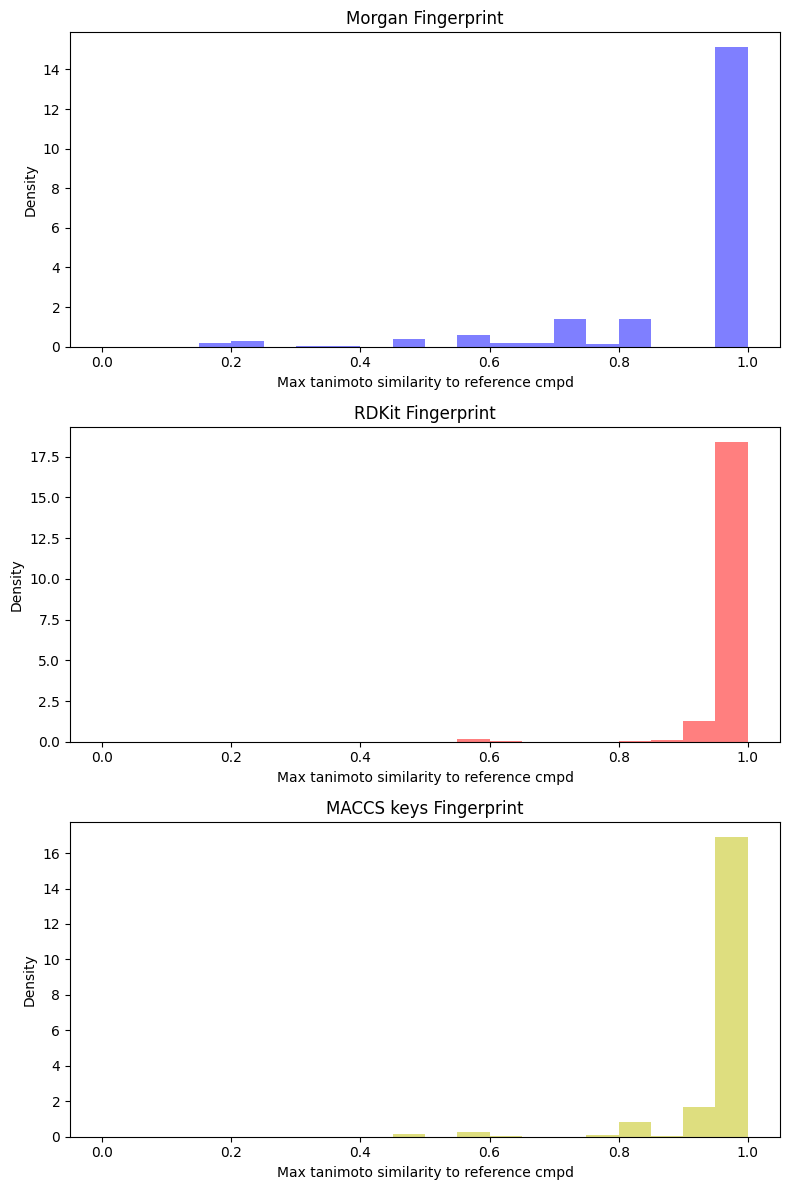

([[1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   0.8378378378378378,
   0.8378378378378378,
   0.6956521739130435,
   0.6956521739130435,
   0.8378378378378378,
   0.8378378378378378,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   0.8382352941176471,
   0.8382352941176471,
   0.723404255319149,
   0.723404255319149,
   0.723404255319149,
   0.723404255319149,
   1.0,
   1.0,
   0.5789473684210527,
   0.5789473684210527,
   0.8378378378378378,
   0.8378378378378378,
   0.723404255319149,
   0.723404255319149,
   0.8378378378378378,
   0.8378378378378378,
   1.0,
   1.0,
   0.8378378378378378,
   0.8378378378378378,
   0.15555555555555556,
   0.15555555555555556,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   0.8382352941176471,
   0.8382352941176471,
   0.723404255319149,
   0.723404255319149,
   1.0,
   1.0,
   1.0,
   1.0,
   0.8378378378378378,
   0.83783783783783

In [6]:
unique_train_e3_smiles = train_df['labels'].apply(lambda label: label.split('.')[0]).unique()
unique_test_e3_smiles = test_df['labels'].apply(lambda label: label.split('.')[0]).unique()
unique_train_e3_mols = [Chem.MolFromSmiles(smiles) for smiles in unique_train_e3_smiles]
unique_test_e3_mols = [Chem.MolFromSmiles(smiles) for smiles in unique_test_e3_smiles]

similarities, dissimilar_mols, indexes = get_tanimoto_distr_2sets(unique_train_e3_mols, [unique_test_e3_mols], FP='morgan')

#print("Tanimoto similarities:", similarities)
total_elements = sum(len(sublist) for sublist in similarities)
print("Tanimoto similarities length:", total_elements)
print('unique e3 number:',len(unique_test_e3_smiles))

plot_tanimoto_similarity_2sets(
    ref_mols=unique_train_e3_mols,
    samples_mols=test_df['labels'].apply(get_e3_mol),
    path='../images/',
    name='tanimoto_similarity_e3'
)

unique linker number: 590


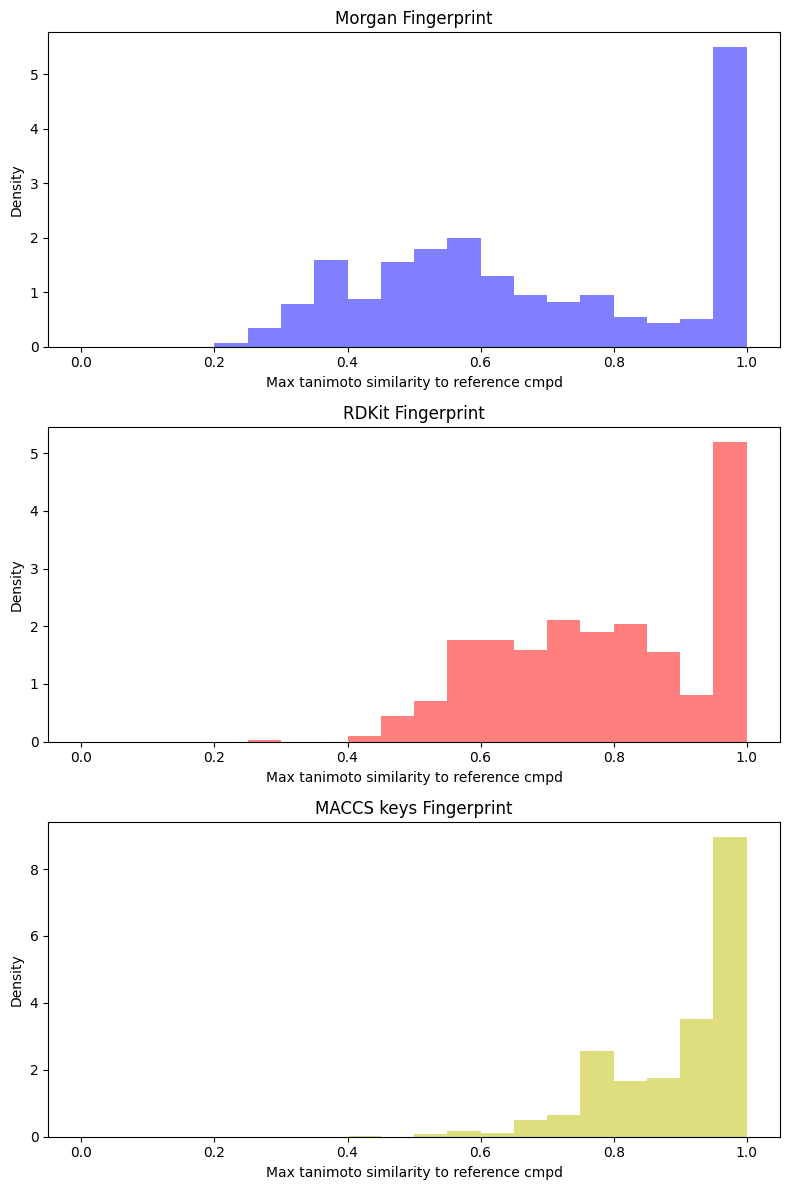

([[0.3333333333333333,
   0.3333333333333333,
   1.0,
   1.0,
   1.0,
   0.23333333333333334,
   0.23333333333333334,
   0.7931034482758621,
   0.6857142857142857,
   0.45,
   0.45,
   0.6190476190476191,
   0.4166666666666667,
   0.4166666666666667,
   1.0,
   1.0,
   1.0,
   0.3387096774193548,
   0.3387096774193548,
   0.5652173913043478,
   1.0,
   1.0,
   0.68,
   1.0,
   0.631578947368421,
   0.3055555555555556,
   1.0,
   0.9642857142857143,
   0.9655172413793104,
   1.0,
   0.9166666666666666,
   1.0,
   1.0,
   0.5652173913043478,
   0.5652173913043478,
   1.0,
   0.65625,
   0.8571428571428571,
   1.0,
   1.0,
   0.8666666666666667,
   1.0,
   1.0,
   0.5,
   1.0,
   0.631578947368421,
   1.0,
   1.0,
   0.6842105263157895,
   1.0,
   1.0,
   1.0,
   0.7931034482758621,
   1.0,
   1.0,
   0.5588235294117647,
   0.4827586206896552,
   0.4827586206896552,
   0.39655172413793105,
   0.39655172413793105,
   0.9090909090909091,
   0.3392857142857143,
   0.3392857142857143,
   0.81

In [8]:
unique_train_linker_smiles = train_df['labels'].apply(lambda label: label.split('.')[1]).unique()
unique_test_linker_smiles = test_df['labels'].apply(lambda label: label.split('.')[1]).unique()
unique_train_linker_mols = [Chem.MolFromSmiles(smiles) for smiles in unique_train_linker_smiles]
unique_test_linker_mols = [Chem.MolFromSmiles(smiles) for smiles in unique_test_linker_smiles]
print('unique linker number:',len(unique_test_linker_smiles))

plot_tanimoto_similarity_2sets(
    ref_mols=unique_train_linker_mols,
    samples_mols=unique_test_linker_mols,
    path='../images/',
    name='tanimoto_similarity_linker'
)

unique poi number: 171


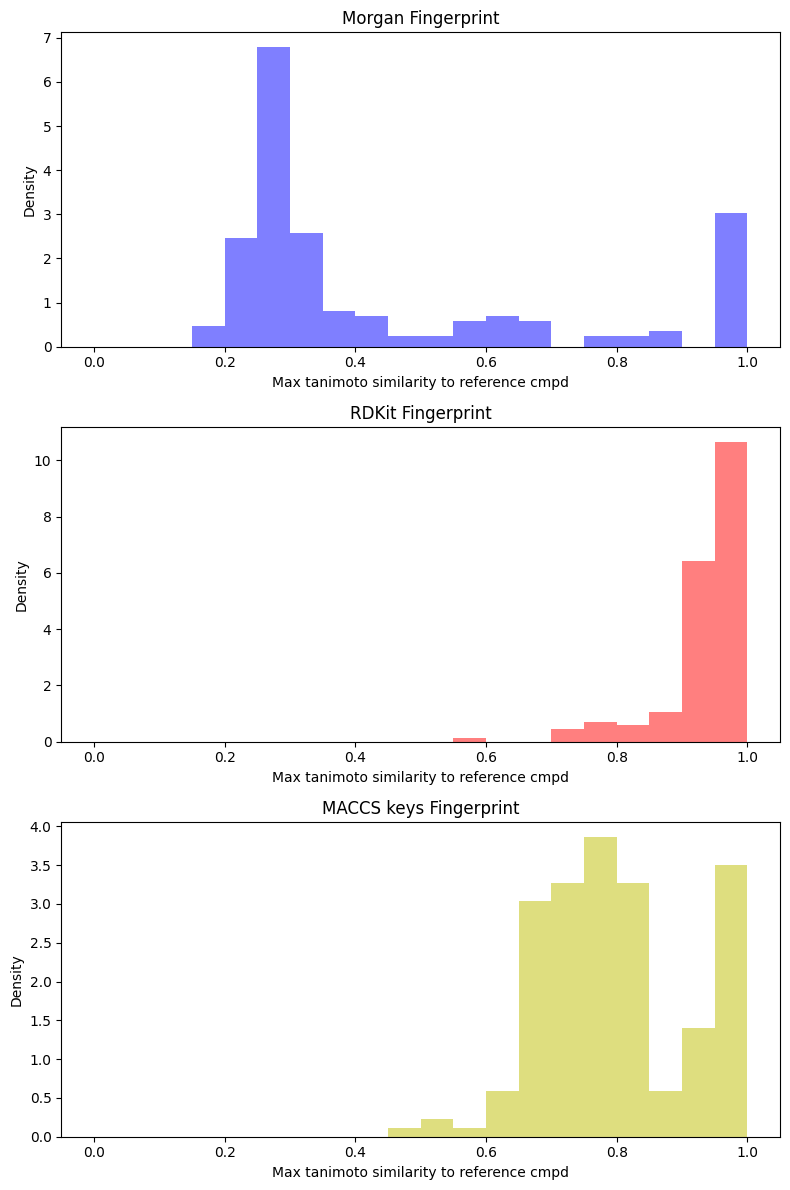

([[0.3670886075949367,
   0.3670886075949367,
   0.25,
   0.2948717948717949,
   0.27848101265822783,
   0.27848101265822783,
   0.6875,
   0.26595744680851063,
   0.26595744680851063,
   0.4772727272727273,
   0.2777777777777778,
   0.2619047619047619,
   0.6111111111111112,
   0.4305555555555556,
   0.4305555555555556,
   0.8732394366197183,
   1.0,
   0.29508196721311475,
   0.2786885245901639,
   0.6727272727272727,
   0.6727272727272727,
   0.22018348623853212,
   0.22018348623853212,
   0.22,
   0.26495726495726496,
   0.26495726495726496,
   0.3142857142857143,
   0.5,
   0.2909090909090909,
   0.8490566037735849,
   1.0,
   0.25252525252525254,
   0.3037974683544304,
   0.24285714285714285,
   0.3235294117647059,
   0.23478260869565218,
   0.23478260869565218,
   0.2375,
   0.2523364485981308,
   0.3670886075949367,
   0.2966101694915254,
   0.25301204819277107,
   0.25301204819277107,
   0.25263157894736843,
   0.27058823529411763,
   0.27058823529411763,
   1.0,
   0.26086956

In [9]:
unique_train_poi_smiles = train_df['labels'].apply(lambda label: label.split('.')[2]).unique()
unique_test_poi_smiles = test_df['labels'].apply(lambda label: label.split('.')[2]).unique()
unique_train_poi_mols = [Chem.MolFromSmiles(smiles) for smiles in unique_train_poi_smiles]
unique_test_poi_mols = [Chem.MolFromSmiles(smiles) for smiles in unique_test_poi_smiles]
print('unique poi number:',len(unique_test_poi_smiles))

plot_tanimoto_similarity_2sets(
    ref_mols=unique_train_poi_mols,
    samples_mols=unique_test_poi_mols,
    path='../images/',
    name='tanimoto_similarity_poi'
)

/tmp/ipykernel_315540/3030629752.py:75: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


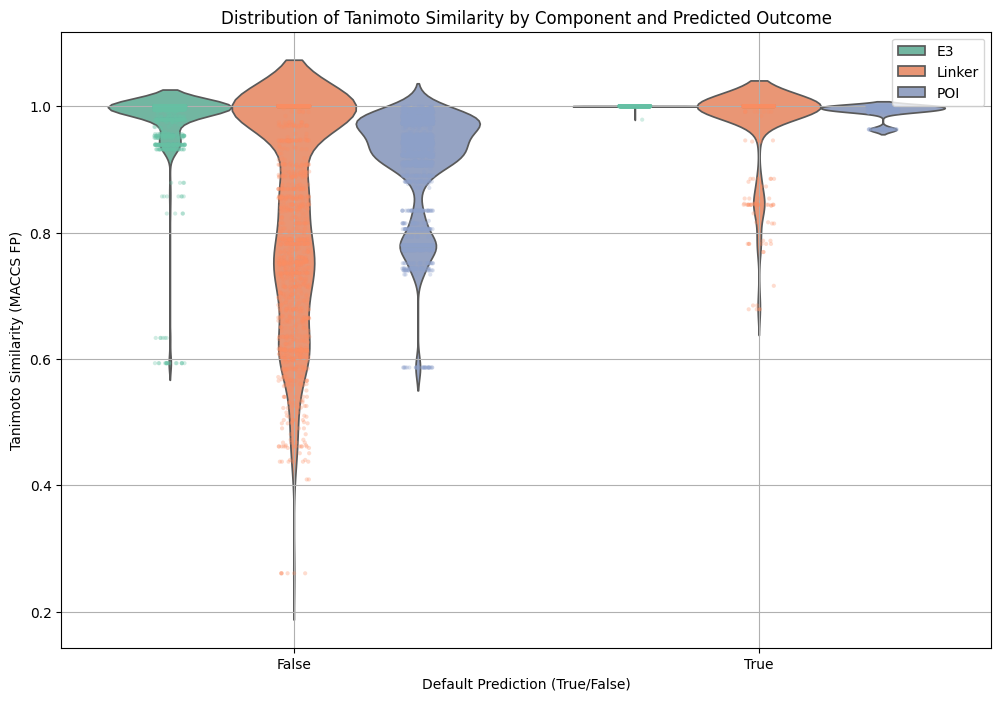

In [ ]:
# Load data
train_df = pd.read_parquet(
    '../PROTAC-Splitter/data/clustered/train-00000-of-00001.parquet')
test_df_1 = pd.read_csv(
    '../PROTAC-Splitter/logs/modelv2_preds.csv') ## get the label with correct order
test_df = pd.read_csv(
    '../PROTAC-Splitter/logs/modelv2_scores.csv')


# Functions to extract molecular components from a dot-separated label SMILES string
def get_e3_mol(label_smiles):
    return Chem.MolFromSmiles(label_smiles.split('.')[0])

def get_linker_mol(label_smiles):
    return Chem.MolFromSmiles(label_smiles.split('.')[1])

def get_poi_mol(label_smiles):
    return Chem.MolFromSmiles(label_smiles.split('.')[2])


# Compute Tanimoto similarities for each component

# For E3 ligase part
unique_e3_smiles = train_df['labels'].apply(lambda s: s.split('.')[0]).unique()
unique_e3_mols = [Chem.MolFromSmiles(s) for s in unique_e3_smiles]
test_e3_mols = test_df_1['label_smiles'].apply(get_e3_mol)

# Calculate similarity distribution between training and test set E3 molecules
similarities_e3, _, _ = get_tanimoto_distr_2sets(unique_e3_mols, [test_e3_mols], FP='rdkit')
tanimoto_similarities_e3 = similarities_e3[0]

# For Linker part
unique_linker_smiles = train_df['labels'].apply(lambda s: s.split('.')[1]).unique()
unique_linker_mols = [Chem.MolFromSmiles(s) for s in unique_linker_smiles]
test_linker_mols = test_df_1['label_smiles'].apply(get_linker_mol)

# Calculate similarity distribution for Linker molecules
similarities_linker, _, _ = get_tanimoto_distr_2sets(unique_linker_mols, [test_linker_mols], FP='rdkit')
tanimoto_similarities_linker = similarities_linker[0]

# For POI part
unique_poi_smiles = train_df['labels'].apply(lambda s: s.split('.')[2]).unique()
unique_poi_mols = [Chem.MolFromSmiles(s) for s in unique_poi_smiles]
test_poi_mols = test_df_1['label_smiles'].apply(get_poi_mol)

# Calculate similarity distribution for POI molecules
similarities_poi, _, _ = get_tanimoto_distr_2sets(unique_poi_mols, [test_poi_mols], FP='rdkit')
tanimoto_similarities_poi = similarities_poi[0]


# Assemble data for plotting

data = pd.DataFrame({
    'Similarity': (tanimoto_similarities_e3 +
                   tanimoto_similarities_linker +
                   tanimoto_similarities_poi),
    'Type': (['E3'] * len(tanimoto_similarities_e3) +
             ['Linker'] * len(tanimoto_similarities_linker) +
             ['POI'] * len(tanimoto_similarities_poi)),
    'Default Prediction': (
        list(test_df['default_pred_n0_e3_equal']) +
        list(test_df['default_pred_n0_linker_equal']) +
        list(test_df['default_pred_n0_poi_equal'])
    )
})


plt.figure(figsize=(12, 8))

# Violin plot: Show the similarity distributions by type and prediction
ax = sns.violinplot(
    x='Default Prediction',
    y='Similarity',
    hue='Type',
    data=data,
    inner=None,
    palette="Set2",
    scale='width'
)

# Overlay: show individual data points as a strip plot
sns.stripplot(
    x='Default Prediction',
    y='Similarity',
    hue='Type',
    data=data,
    size=3,
    alpha=0.3,
    palette="Set2",
    dodge=True
)

plt.xlabel('Default Prediction (True/False)')
plt.ylabel('Tanimoto Similarity (MACCS FP)')
plt.title('Distribution of Tanimoto Similarity by Component and Predicted Outcome')
plt.grid(True)

# Remove duplicate legends by only showing one set
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles[:3], labels[:3])
plt.show()

In [ ]:

# molecular visualazation, calculate relative difference


def count_non_dummy_atoms(mol):
    """Count atoms that are not dummy atoms ([*])"""
    return sum(1 for atom in mol.GetAtoms() if atom.GetSymbol() != '*')

def absolute_mcs_difference(label_mol, pred_mol, name=""):
    """Calculate absolute difference based on MCS"""
    if not label_mol or not pred_mol:
        return {"name": name, "error": "Molecule parsing failed", "relative_diff": np.nan}
  
    # Calculate MCS
    mcs = rdFMCS.FindMCS([label_mol, pred_mol], completeRingsOnly=True)
    mcs_mol = Chem.MolFromSmarts(mcs.smartsString) if mcs.smartsString else None
  
    if not mcs_mol:
        return {"name": name, "error": "No common substructure found", "relative_diff": np.nan}
  
    # Count atoms
    label_atoms = label_mol.GetNumHeavyAtoms()
    pred_atoms = pred_mol.GetNumHeavyAtoms()
    mcs_atoms = mcs_mol.GetNumAtoms()
  
    label_atoms = count_non_dummy_atoms(label_mol)
    pred_atoms = count_non_dummy_atoms(pred_mol)
    mcs_atoms = count_non_dummy_atoms(mcs_mol)

  
    label_diff = label_atoms - mcs_atoms
    pred_diff = pred_atoms - mcs_atoms
  
    # Calculate total absolute difference
    total_abs_diff = label_diff + pred_diff
  
    # Calculate relative difference, with direction
    if label_diff == 0:
        relative_diff = pred_diff
    elif pred_diff == 0:
        relative_diff = -label_diff
    else:
        # Both have extra atoms
        relative_diff = total_abs_diff
  
    # Get atom indices for visualization
    match_label = label_mol.GetSubstructMatch(mcs_mol)
    match_pred = pred_mol.GetSubstructMatch(mcs_mol)
  
    unmatched_label = [i for i in range(label_mol.GetNumAtoms()) if i not in match_label]
    unmatched_pred = [i for i in range(pred_mol.GetNumAtoms()) if i not in match_pred]
  
    # Generate description
    if total_abs_diff == 0:
        description = "Molecules are identical"
    else:
        # Build description based on logic
        if label_diff == 0:
            description = f"Pred has {pred_diff} more atoms than Label (+{pred_diff})"
        elif pred_diff == 0:
            description = f"Pred has {label_diff} fewer atoms than Label (-{label_diff})"
        else:
            description = f"Label has {label_diff} atoms not in MCS, Pred has {pred_diff} atoms not in MCS, total difference: {total_abs_diff} atoms"
  
    return {
        "name": name,
        "mcs_atoms": mcs_atoms,
        "label_diff": label_diff,
        "pred_diff": pred_diff,
        "total_abs_diff": total_abs_diff,
        "relative_diff": relative_diff,
        "description": description,
        "unmatched_label": unmatched_label,
        "unmatched_pred": unmatched_pred
    }


def split_smiles_to_components(smiles):
    """Split SMILES string into components"""
    return smiles.split('.')

def analyze_protac_components(df):
    """Analyze PROTAC components and add MCS difference metrics to the dataframe"""
    # Create new columns for MCS differences
    df['mcs_e3_relative_diff'] = np.nan
    df['mcs_linker_relative_diff'] = np.nan
    df['mcs_poi_relative_diff'] = np.nan
  
    for idx, row in df.iterrows():
        Compound_Name = row['Compound Name']
        label_smiles = row['label_smiles']
        pred_smiles = row['default_pred_n0']
  
        # Split components
        try:
            label_components = split_smiles_to_components(label_smiles)
            pred_components = split_smiles_to_components(pred_smiles)
  
            if len(label_components) != 3 or len(pred_components) != 3:
                print(f"SMILES format error at row {idx}, Compound: {Compound_Name}")
                continue
  
            ligand_names = ['E3', 'Linker', 'POI']
            for i, ligand in enumerate(ligand_names):
                ligand_label_mol = Chem.MolFromSmiles(label_components[i])
                ligand_pred_mol = Chem.MolFromSmiles(pred_components[i])
  
                # Perform MCS analysis
                result = absolute_mcs_difference(ligand_label_mol, ligand_pred_mol, ligand)
  
                # Store relative difference in dataframe
                if 'relative_diff' in result and not np.isnan(result['relative_diff']):
                    column_name = f"mcs_{ligand.lower()}_relative_diff"
                    df.at[idx, column_name] = result['relative_diff']
  
        except Exception as e:
            print(f"Error processing row {idx}, Compound: {Compound_Name}: {str(e)}")
  
    return df

def display_protac_analysis(filtered_df, num_rows=6):
    """Display detailed analysis for the first n rows of the filtered dataframe"""
    for idx, row in filtered_df.head(num_rows).iterrows():
        Compound_Name = row['Compound Name']
        protac_smiles = row['protac_smiles']
        label_smiles = row['label_smiles']
        pred_smiles = row['default_pred_n0']

        # Generate molecule objects for visualization
        protac_mol = Chem.MolFromSmiles(protac_smiles)
        label_full_mol = Chem.MolFromSmiles(label_smiles)  # 3 components
        pred_full_mol = Chem.MolFromSmiles(pred_smiles)

        # Print existing metrics
        # print(f"Compound_Name: {Compound_Name}")
        # e3_g = row.get('default_pred_n0_e3_graph_edit_distance', None)
        # e3_h = row.get('default_pred_n0_e3_heavy_atoms_difference', None)
        # poi_g = row.get('default_pred_n0_poi_graph_edit_distance', None)
        # poi_h = row.get('default_pred_n0_poi_heavy_atoms_difference', None)
        # linker_g = row.get('default_pred_n0_linker_graph_edit_distance', None)
        # linker_h = row.get('default_pred_n0_linker_heavy_atoms_difference', None)

        # print("E3: GED={:.3f}, HeavyAtomDiff={:.3f}".format(e3_g, e3_h))
        # print("POI: GED={:.3f}, HeavyAtomDiff={:.3f}".format(poi_g, poi_h))
        # print("Linker: GED={:.3f}, HeavyAtomDiff={:.3f}".format(linker_g, linker_h))
  
        # Print MCS relative differences
        e3_rel = row.get('mcs_e3_relative_diff', np.nan)
        linker_rel = row.get('mcs_linker_relative_diff', np.nan)
        poi_rel = row.get('mcs_poi_relative_diff', np.nan)
  
        print("MCS Relative Differences (positive=Pred larger, negative=Label larger):")
        print(f"  E3: {e3_rel if not np.isnan(e3_rel) else 'N/A'}")
        print(f"  Linker: {linker_rel if not np.isnan(linker_rel) else 'N/A'}")
        print(f"  POI: {poi_rel if not np.isnan(poi_rel) else 'N/A'}")

        # Analyze components with MCS
        label_components = split_smiles_to_components(label_smiles)
        pred_components = split_smiles_to_components(pred_smiles)
  
        if len(label_components) != 3 or len(pred_components) != 3:
            print(f"SMILES format error at row {idx}!")
            continue
  
        ligand_names = ['E3', 'Linker', 'POI']
        for i, ligand in enumerate(ligand_names):
            ligand_label_mol = Chem.MolFromSmiles(label_components[i])
            ligand_pred_mol = Chem.MolFromSmiles(pred_components[i])
  
            if ligand_label_mol and ligand_pred_mol:
                # Perform MCS analysis and display results
                result = absolute_mcs_difference(ligand_label_mol, ligand_pred_mol, ligand)
  
                if 'error' in result:
                    print(f"{ligand}: {result['error']}")
                    continue
  
                print(f"\n{ligand}:")
                print(f"  MCS: {result['mcs_atoms']} atoms")
                print(f"  Label vs MCS: {result['label_diff']} atoms")
                print(f"  Pred vs MCS: {result['pred_diff']} atoms")
                print(f"  Total absolute difference: {result['total_abs_diff']} atoms")
                print(f"  Relative difference: {result['relative_diff']} atoms")
                print(f"  Conclusion: {result['description']}")
  
                # Visualize differences
                # Visualize all molecules, regardless of differences
                highlight_atoms = [result.get('unmatched_label', []), result.get('unmatched_pred', [])]
                highlight_colors = [
                    {i: (1, 0, 0) for i in result.get('unmatched_label', [])},
                    {i: (1, 0, 0) for i in result.get('unmatched_pred', [])}
                ]
  
                # Create molecule grid image
                img_diff = Draw.MolsToGridImage(
                    [ligand_label_mol, ligand_pred_mol],
                    molsPerRow=2,
                    subImgSize=(300, 250),
                    legends=[f'{ligand} Label', f'{ligand} Pred'],
                    highlightAtomLists=highlight_atoms,
                    highlightAtomColors=highlight_colors
                )
                display(img_diff)
  
                # Optional: display difference information
                if result.get('unmatched_label') or result.get('unmatched_pred'):
                    print(f"{ligand}: {result.get('description', 'Differences detected')}")
                else:
                    print(f"{ligand}: Molecules are identical")
            else:
                print(f"{ligand}: Molecule parsing failed.")

        print("-" * 50)  # Separator for each row

        # Display the full molecules
        if protac_mol and label_full_mol and pred_full_mol:
            img = Draw.MolsToGridImage(
                [protac_mol, label_full_mol, pred_full_mol],
                molsPerRow=3,
                subImgSize=(400, 300),
                legends=['Protac', 'Label', 'Prediction']
            )
            display(img)
  
        print("=" * 80)  # Clear separator between compounds


In [ ]:
# apply on prediction result

pred_df = pd.read_csv('../logs/XGBoost_preds.csv') # prediction result

# Add MCS analysis to the dataframe
pred_df = analyze_protac_components(pred_df)

# Display detailed analysis for the first few rows
display_protac_analysis(pred_df, num_rows=6)

# You can now use the enriched dataframe for further analysis
print("\nDataFrame with MCS relative differences:")
print(pred_df[['Compound Name', 'mcs_e3_relative_diff', 'mcs_linker_relative_diff', 'mcs_poi_relative_diff']].head())


In [ ]:
# histogram for relative difference

plt.figure(figsize=(15, 5))

columns = ['mcs_e3_relative_diff', 'mcs_linker_relative_diff', 'mcs_poi_relative_diff']
titles = ['E3 MCS Relative Difference', 'Linker MCS Relative Difference', 'POI MCS Relative Difference']

# Draw three histograms
for i, (col, title) in enumerate(zip(columns, titles)):
    plt.subplot(1, 3, i+1)  # 1 row, 3 columns layout

    data = pred_df[col].dropna()

    # count for 0 difference
    count_zero = (data == 0).sum()

    n, bins, patches = plt.hist(data, bins=20, alpha=0.7, color=f'C{i}')

    plt.title(title)
    plt.xlabel('Relative Difference (atoms)')
    plt.ylabel('Count')

    plt.grid(True, linestyle='--', alpha=0.5)

 
    zero_bin_idx = (np.digitize(0, bins) - 1)
    
    zero_bin_center = (bins[zero_bin_idx] + bins[zero_bin_idx + 1]) / 2

    plt.text(zero_bin_center, n[zero_bin_idx] + max(n)*0.03, 
             f'n={count_zero}', color='red', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()